## Analyze model predictions from latent code using PCA, tSNE, and UMAP
---
*Last edited 8 Sep 2026 by K. Wolcott*

In [1]:
# Read in data from latent codes for training attempt
import os, re, json, torch, numpy as np, pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from pathlib import Path

# Specify training directory that contains config.json, latent_codes/, and model/
cwd = Path.cwd()
base_wd = cwd.parent 
train_dir = base_wd / 'run_v72' # TO DO: Update to relevant training attempt directory
os.chdir(train_dir)

# Specify model ckpt to use
CKPT = '2500' # TO DO: Choose the ckpt value you want to analyze results for

# Load config
config_path = 'model_params_config.json'
try:
    with open(config_path, 'r') as f:
        cfg = json.load(f)
    print(f"\033[92mLoaded config from {config_path}\033[0m")
except FileNotFoundError:
    print(f"\033[31mError: model_params_config.json not found in {config_path}. Exiting.\033[0m")

# Get training paths from config
train_paths = cfg['list_mesh_paths']
all_vtk_files = [os.path.basename(f) for f in train_paths]

# Parse species and vertebra info from filenames (e.g. "H-capensis-22-L8.ply_align.vtk").
pat = re.compile(r"^(?P<species>[\w\s\-]+)[\-_ ]+\d+[\-_ ]+(?P<vertebra>[CTL]\d+)", re.IGNORECASE)
labels = []
unmatched_files = []
for f in all_vtk_files:
    fname = os.path.basename(f)
    m = pat.match(fname)
    if m:
        species = m.group("species").strip()
        vertebra = m.group("vertebra").strip()  # e.g. "C2", "L8"
        labels.append((species, vertebra))
    else:
        labels.append((None, None))
        unmatched_files.append(fname)

# Load latent codes from the single .pth file.
CKPT_PATH = 'latent_codes' + '/' + CKPT + '.pth'
latent_ckpt = torch.load(CKPT_PATH, map_location="cpu") 
codes = latent_ckpt['latent_codes']['weight'].detach().cpu().numpy()

Loaded config from model_params_config.json


/tmp/ipykernel_264683/3347267776.py:46: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  latent_ckpt = torch.load(CKPT_PATH, map_location="cpu")


## Statistical analysis of model performance - PCA, tSNE, UMAP
---

In [ ]:
# Define functions for plotting
import seaborn as sns
from pathlib import Path
from itertools import combinations
from matplotlib.colors import LinearSegmentedColormap
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle
from statsmodels.multivariate.manova import MANOVA
from statsmodels.stats.multitest import multipletests

# Get marker based on life history of species
def get_marker(species):
    species = species.lower()
    if any(k in species for k in ["chalcides", "tetradactylus", "chamaesaura", "takydromus"]):  # swims in grass
        return 'P' # plus filled
    elif any(k in species for k in ["skoog", "eremiascincus", "_scincus"]): # swims in sand
        return '+'  # plus regular
    elif any(k in species for k in ["acontias", "mochlus", "rhineura", "dibamus", "lanthanotus", "bipes", "diplometopon", "pseudopus", "bachia", "polychrous"]):  # burrowing
        return 's'  # square
    elif any(k in species for k in ["jonesi", "corucia", "gecko", "chamaeleo", "iguana", "brookesia", "dracaena", "anolis", "basiliscus", 
                                    "dracaena", "aristelliger", "sceloporus", "lialis", "phyllurus", "draco", "hoplodactylus"]):  # arboreal
        return 'd' # thin diamond
    elif any(k in species for k in ["elgaria", "smaug_giganteus", "broadleysaurus", "ateuchosaurus", "alopoglossus", "heloderma", "tupinambis",
                                    "carlia", "lipinia", "tiliqua", "tribolonotus", "leiolepis", "eublepharis", "oreosaurus", "baranus",
                                    "callopistes", "cricosaura", "lepidophyma", "sphenodon", "lacerta", "enyaloides", "crocodilurus"]):  # terrestrial
        return 'X' # x filled
    elif any(k in species for k in ["eryx", "homalopsis", "aniolios"]):   # snake
        return '2' #
    else:                      # saxicolous/rock dwelling
        return 'o'  # circle (default)
    
# Make a reference legend for marker symbols
# Define markers and their corresponding life history strategy labels
legend_items = [('P', 'GRASS SWIMMER'),
                ('+', 'SAND SWIMMER'),
                ('s', 'BURROWER'),
                ('d', 'ARBOREAL'),
                ('X', 'TERRESTRIAL'),
                ('o', 'SAXICOLOUS'),
                ('2', "SNAKE")]

# Light to full color cmap (workaroun for seaborn kde shading)
def get_gradient_cmap(color, n=256, white_level=0.8):
    light = tuple(c + (1 - c) * white_level for c in color)
    return LinearSegmentedColormap.from_list("gradient_cmap", [light, color], N=n)

# Define a color map for different life history strategies (marker types)
markers = ['P', '+', 's', 'd', 'X', 'o', '2']
colors =    [(0.65, 0.69, 0.12),  # pea soup 
            (0.84, 0.65, 0.23),  # saffron
            (0.72, 0.44, 0.22), # mud
            (0.36, 0.557, 0.68),  # powder blue
            (0.10, 0.51, 0.40),  # deft blue
            (0.60, 0.50, 0.46),  # slate
            (0,0,0)]   
marker_to_color = dict(zip(markers, colors))

# Plot style
FONTSIZE = 11
plt.rcParams.update({"font.family": "sans-serif",
                     "font.sans-serif": ["Liberation Sans", "DejaVu Sans"],
                     "font.size": FONTSIZE,
                     "pdf.fonttype": 42})

# Build plotting params
SKIP = {'2'}                                                # Exclude snakes (only 3 datapoints)
MARKERS = [m for m, _ in legend_items if m not in SKIP]            
marker_to_label = dict(legend_items)

# Format MANOVA table outputs for paper

def fmt_p(val, significant=False):
    if pd.isna(val):
        return 'NaN'
    if val == 0:
        s = '< 1e-300'
    else:
        exp = int(np.floor(np.log10(abs(val))))
        s = f'{val / 10**exp:.2f}e{exp:+03d}'
    return s + ('*' if significant else '')

def format_main_manova(df):
    out = df.copy()
    for col in ['Num DF', 'Den DF', 'F Value']:
        out[col] = out[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN')
    out['Value'] = out['Value'].apply(lambda x: f'{x:.4f}' if pd.notna(x) else 'NaN')
    out['Pr > F'] = out['Pr > F'].apply(fmt_p)
    return out

def format_pairwise_manova(df):
    out = df.drop(columns=['significant', 'note'], errors='ignore').copy()
    sig = df['significant'] if 'significant' in df.columns else pd.Series(False, index=df.index)
    out["Wilks' lambda"] = out["Wilks' lambda"].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN')
    for col in ['Num DF', 'Den DF', 'F Value']:
        if col in out.columns:
            out[col] = out[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'NaN')
    out['p-value'] = [fmt_p(v, s) for v, s in zip(df['p-value'], sig)]
    out['p-value (FDR corrected)'] = [fmt_p(v, s) for v, s in zip(df['p-value (FDR corrected)'], sig)]
    return out

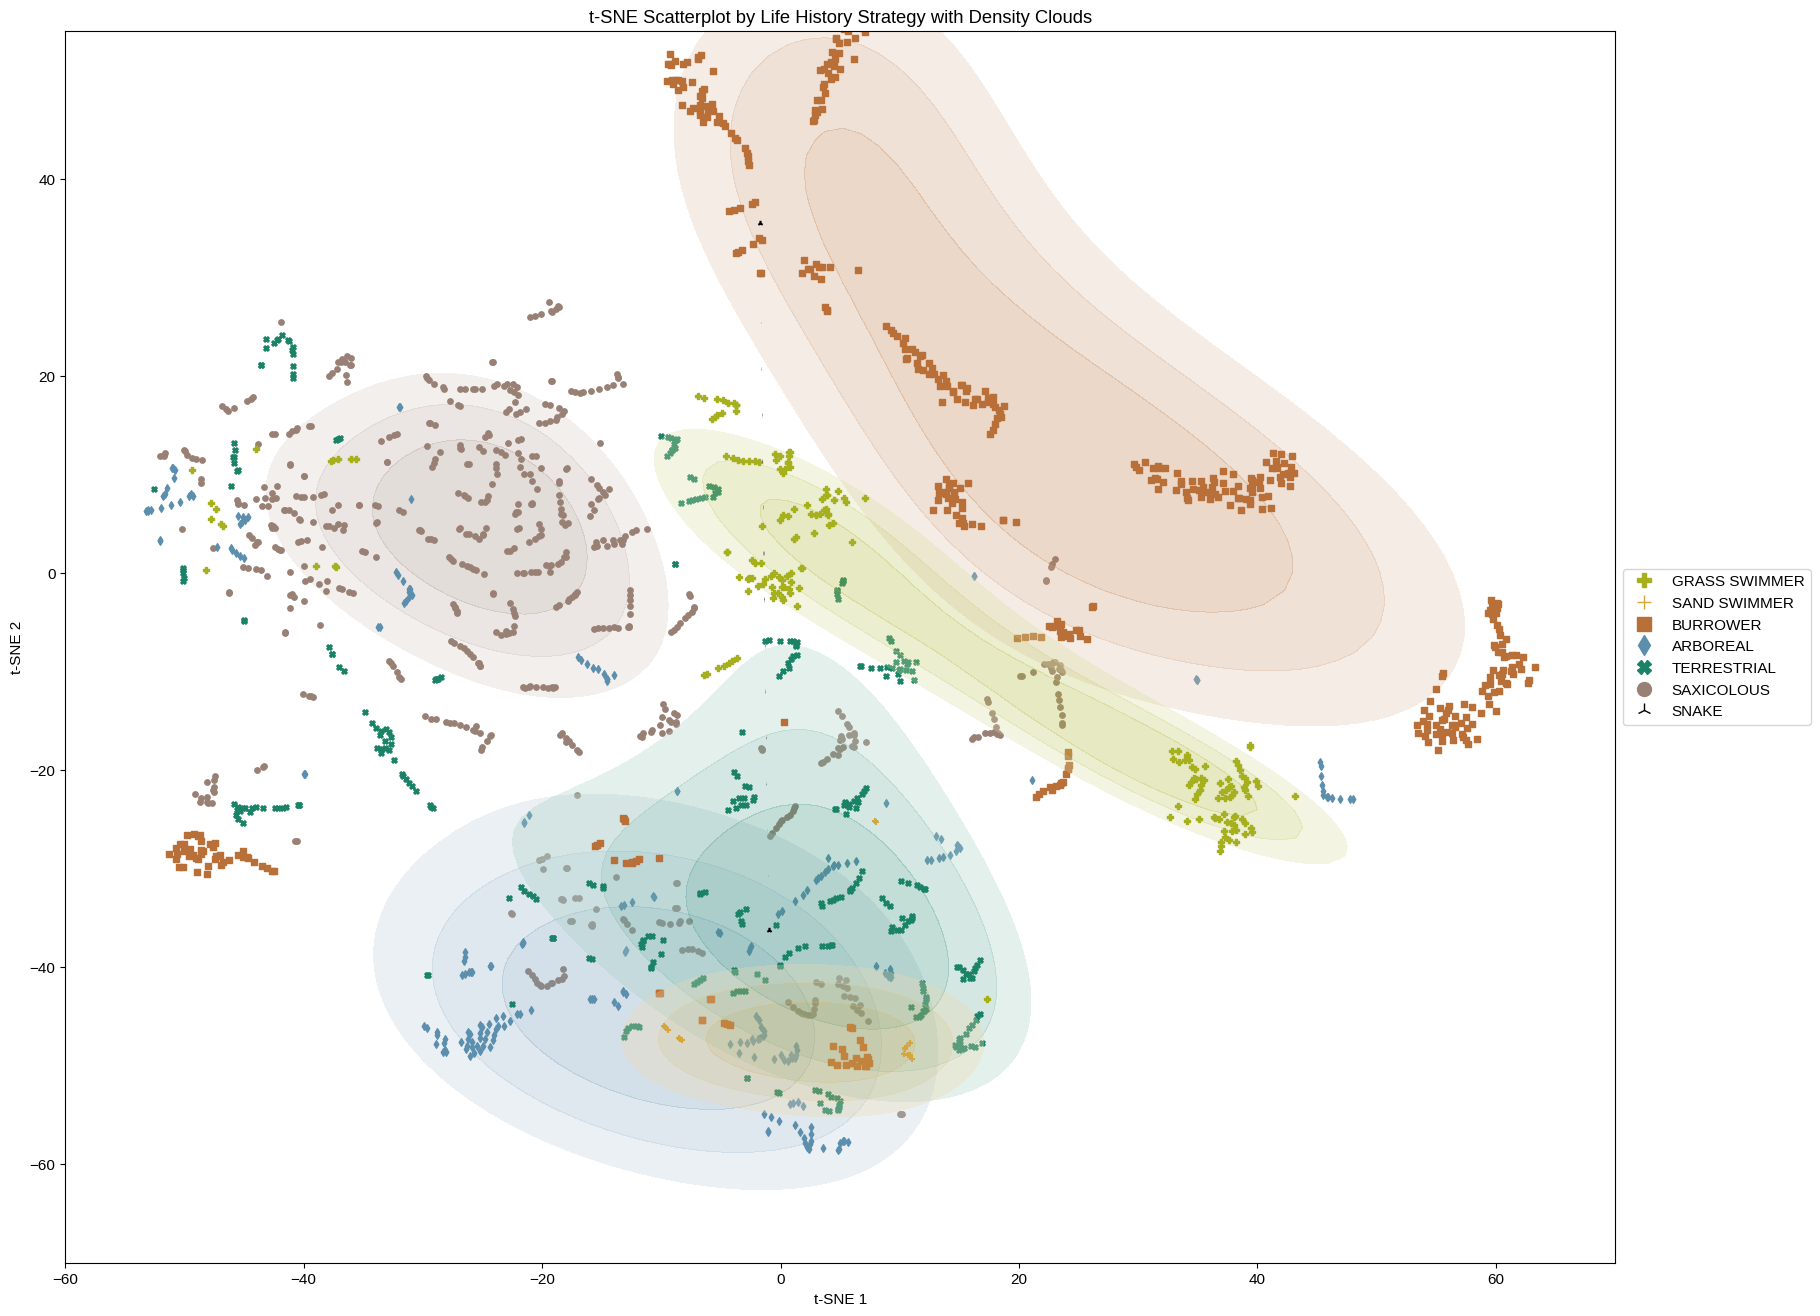

In [3]:
# Try with tSNE

# Run t-SNE to reduce to 2D
tsne = TSNE(n_components=2, 
            perplexity=40, 
            learning_rate=200,
            early_exaggeration=12,
            n_iter_without_progress=2000,
            random_state=42)
tsne_coords = tsne.fit_transform(codes)

# Group tSNE results by strategy (life history strategy)
strategy_groups_tsne = defaultdict(list)
for i, (species, vertebra) in enumerate(labels):
    if species is not None and vertebra is not None:  # exclude snakes
        strategy = get_marker(species)
        strategy_groups_tsne[strategy].append((vertebra, tsne_coords[i, 0], tsne_coords[i, 1]))

# Plot tSNE with KDE plots
plt.figure(figsize=(20,16))
plt.xlim(-60, 70)
plt.ylim(-70, 55)

for strategy, points in strategy_groups_tsne.items():
    points_sorted = sorted(points, key=lambda x: (x[0], x[1]))  # Sort by vertebra label if needed
    vertebra_labels, tsne1_vals, tsne2_vals = zip(*points_sorted)
    
    # Generate custom color palette for kdeplot (default uses grey to white shades of each color)
    cmap = get_gradient_cmap(marker_to_color[strategy], white_level=0.7)
    
    # Plot density cloud for each strategy (life history strategy marker)
    if strategy == '2':  # Skip snake
        pass
    sns.kdeplot(x=tsne1_vals, y=tsne2_vals, fill=True, cmap=cmap, alpha=0.3, bw_adjust=1.9, cut=5.0, thresh=0.7, levels=4)

    # Scatter plot the points with their corresponding marker
    plt.scatter(tsne1_vals, tsne2_vals, marker=strategy, color=marker_to_color[strategy], label=strategy, s=15)

# Customize labels and title
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title("t-SNE Scatterplot by Life History Strategy with Density Clouds")

# Customize the legend using the provided legend items
handles = [plt.Line2D([0], [0], marker=marker, linestyle="None", markerfacecolor=marker_to_color[marker], markeredgecolor=marker_to_color[marker], markersize=10) for marker, _ in legend_items]
llabels = [label for _, label in legend_items]

# Display the customized legend
plt.legend(handles=handles, labels=llabels, loc='center left', bbox_to_anchor=(1, 0.5))
outfpath = os.path.split(os.getcwd())[1] + '_tsne_with_density_and_strategy_colors.png'
plt.savefig(outfpath, dpi=300, bbox_inches='tight')
plt.show()

Explained variance per LDA component: [0.47718455 0.23406528 0.11859948 0.08757556 0.06278295 0.01979218]


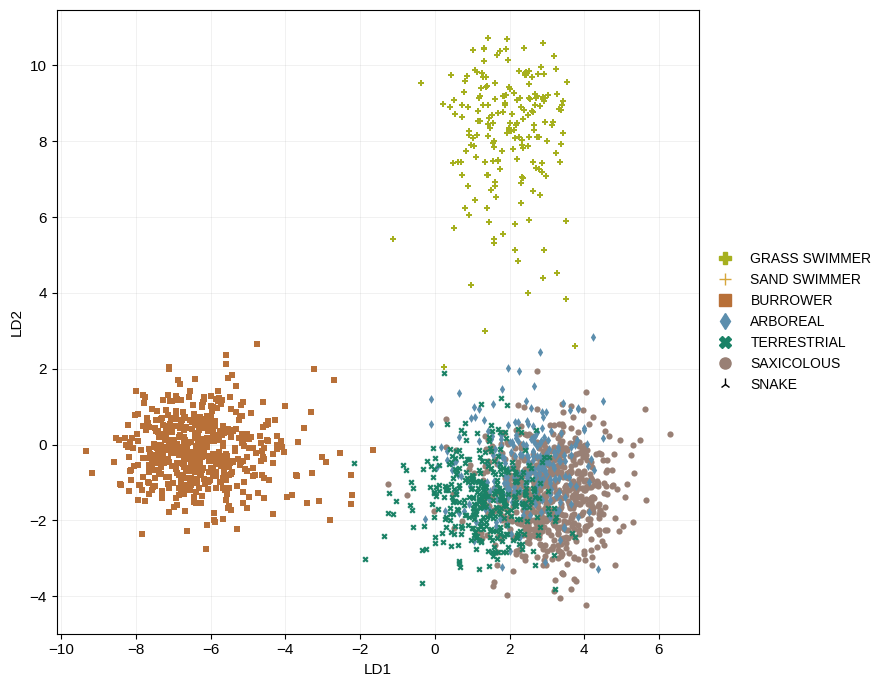

In [4]:
# Use LDA on PCA of latent codes to see if groups identified from tSNE KDE are meaningful

# Filter out entries where species or vertebra is None
filtered_data = [(label, code) for label, code in zip(labels, codes)
                 if label[0] is not None
                 and label[1] is not None]  

# Unpack filtered labels and codes
filtered_labels, filtered_codes = zip(*filtered_data)

# Now create your y with valid markers
y = [get_marker(species) for species, vertebra in filtered_labels]
scaler = StandardScaler()
filtered_codes_scaled = scaler.fit_transform(filtered_codes)
pca = PCA(n_components=0.99)
pca_all_codes = pca.fit_transform(filtered_codes_scaled)
X = pca_all_codes

# Fit LDA
lda = LDA(solver='svd', n_components=None)  
X_lda = lda.fit_transform(X, y)

# Check explained variance ratio
explained_variance = lda.explained_variance_ratio_
print("Explained variance per LDA component:", explained_variance)

# Plot LDA project
fig, ax = plt.subplots(figsize=(9.0, 7.0))

for marker in set(y):
    idx = [i for i, val in enumerate(y) if val == marker]
    ax.scatter(X_lda[idx, 0], X_lda[idx, 1],
               marker=marker, color=marker_to_color[marker],
               s=20, linewidths=0, rasterized=True)

ax.set_xlabel("LD1")
ax.set_ylabel("LD2")
ax.grid(alpha=0.25, lw=0.5)
ax.set_axisbelow(True)

handles = [plt.Line2D([0], [0], marker=marker, linestyle="None",
               markerfacecolor=marker_to_color[marker],
               markeredgecolor=marker_to_color[marker], markersize=8)
               for marker, _ in legend_items]
llabels = [label for _, label in legend_items]
ax.legend(handles=handles, labels=llabels,
          fontsize=FONTSIZE - 1, frameon=False,
          loc='center left', bbox_to_anchor=(1, 0.5))

fig.tight_layout()
outfpath = os.path.split(os.getcwd())[1] + '_lda_by_strategy.png'
fig.savefig(outfpath, dpi=300, bbox_inches='tight')
plt.show(fig)
plt.close(fig)


In [5]:
# MANOVA - between groups and pairwise

marker_to_label = dict(legend_items)

# Build LD DataFrame once
df_lda = pd.DataFrame(X_lda, columns=[f"LD{i+1}" for i in range(X_lda.shape[1])])
df_lda['group'] = y

print("Samples per group:")
print(df_lda['group'].value_counts().rename(index=marker_to_label).to_string())
print(f"LD dimensions: {X_lda.shape[1]}\n")

# Overall MANOVA
formula = ' + '.join([c for c in df_lda.columns if c != 'group'])
manova = MANOVA.from_formula(f'{formula} ~ group', data=df_lda)
mv_result = manova.mv_test()
print(mv_result)

# Pairwise MANOVA in LD space
n_features = X_lda.shape[1]
pairwise_results = []

for g1, g2 in combinations(sorted(set(y)), 2):
    df_pair = df_lda[df_lda['group'].isin([g1, g2])]
    counts = df_pair['group'].value_counts()

    if counts.min() <= n_features:
        print(f"Underpowered: {marker_to_label[g1]} vs {marker_to_label[g2]} "
              f"(n={counts.min()}, features={n_features})")
        pairwise_results.append({'Group 1': marker_to_label.get(g1, g1),
                                 'Group 2': marker_to_label.get(g2, g2),
                                 "Wilks' lambda": np.nan,
                                 'p-value': np.nan,
                                 'note': 'underpowered'})
        continue

    stats_df = MANOVA.from_formula(f'{formula} ~ group', data=df_pair).mv_test().results['group']['stat']
    wilks_row = stats_df.loc["Wilks' lambda"]
    pairwise_results.append({'Group 1': marker_to_label.get(g1, g1),
                             'Group 2': marker_to_label.get(g2, g2),
                             "Wilks' lambda": wilks_row['Value'],
                             'Num DF': wilks_row['Num DF'],
                             'Den DF': wilks_row['Den DF'],
                             'F Value': wilks_row['F Value'],
                             'p-value': wilks_row['Pr > F'],
                             'note': ''})

pairwise_df = pd.DataFrame(pairwise_results)

# FDR correction on valid p-values only
valid_mask = pairwise_df['p-value'].notna()
reject, p_corrected, _, _ = multipletests(pairwise_df.loc[valid_mask, 'p-value'].values, method='fdr_bh')
pairwise_df['p-value (FDR corrected)'] = np.nan
pairwise_df['significant'] = False
pairwise_df.loc[valid_mask, 'p-value (FDR corrected)'] = p_corrected
pairwise_df.loc[valid_mask, 'significant'] = reject
pairwise_df.sort_values('p-value', inplace=True)

# Save main table
main_manova_df = pd.concat([mv_result.results[s]['stat'].assign(term=s) for s in ['Intercept', 'group']])
main_manova_df.insert(0, 'term', main_manova_df.pop('term'))
format_main_manova(main_manova_df).to_csv('manova_main.csv')
print("\nSaved: manova_main.csv")

# Save pairwise table
pairwise_out = format_pairwise_manova(pairwise_df)
print(pairwise_out.to_string(index=False))
pairwise_out.to_csv('manova_pairwise.csv', index=False)
print("Saved: manova_pairwise.csv")

Samples per group:
group
SAXICOLOUS       647
BURROWER         536
TERRESTRIAL      346
ARBOREAL         243
GRASS SWIMMER    191
SAND SWIMMER      17
SNAKE              2
LD dimensions: 6

                     Multivariate linear model
                                                                   
-------------------------------------------------------------------
           Intercept        Value  Num DF   Den DF  F Value  Pr > F
-------------------------------------------------------------------
              Wilks' lambda 0.3207 6.0000 1970.0000 695.5547 0.0000
             Pillai's trace 0.6793 6.0000 1970.0000 695.5547 0.0000
     Hotelling-Lawley trace 2.1184 6.0000 1970.0000 695.5547 0.0000
        Roy's greatest root 2.1184 6.0000 1970.0000 695.5547 0.0000
-------------------------------------------------------------------
                                                                   
-------------------------------------------------------------------
         group 